# Final GMM C5 Customer Membership Analysis  
## Posterior probabilities, alternative components and assignment uncertainty

### Purpose

The previous notebook selected and froze `GMM_C5_spherical` as the final
five-component Gaussian Mixture Model.

This notebook does **not** retrain the model.

It loads the saved final GMM and evaluates customer-level membership using:

- assigned component;
- maximum posterior probability;
- second-highest posterior probability;
- probability margin;
- most likely alternative component;
- normalised membership entropy;
- individual Silhouette Value;
- descriptive membership-confidence categories;
- component-level uncertainty;
- overlap between assigned and alternative components;
- sensitivity to the descriptive confidence thresholds.

## Relationship with the K-Means confidence analysis

The two models express customer uncertainty differently:

### K-Means

- individual Silhouette Value;
- distance to assigned centroid;
- distance to second-nearest centroid;
- relative centroid margin.

### GMM

- posterior component probabilities;
- maximum probability;
- second-highest probability;
- probability margin;
- membership entropy.

This notebook creates the GMM confidence layer required for the later
K-Means-versus-GMM comparison and dashboard.

## 1. Import libraries

In [ ]:
import os
import json
import shutil
import zipfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure input files and output folders

Upload these three files to Colab:

1. `customer_features_processed.csv`
2. `customer_features_ready_for_preprocessing.csv`
3. `Final_GMM_C5_Spherical_vs_Diagonal_Results.zip`

The ZIP contains the frozen model and final five-component assignments.

In [ ]:
PROCESSED_FILE = (
    "/content/customer_features_processed.csv"
)

ORIGINAL_SCALE_FILE = (
    "/content/"
    "customer_features_ready_for_preprocessing.csv"
)

FROZEN_GMM_RESULTS_ZIP = (
    "/content/"
    "Final_GMM_C5_Spherical_vs_Diagonal_Results.zip"
)

SOURCE_EXTRACT_DIR = Path(
    "/content/Frozen_GMM_C5_Source"
)

RESULTS_DIR = Path(
    "/content/GMM_C5_Membership_Probability_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
DATASETS_DIR = RESULTS_DIR / "Datasets"
QUALITY_DIR = RESULTS_DIR / "Quality_Checks"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    DATASETS_DIR,
    QUALITY_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

EXPECTED_CUSTOMERS = 4338
EXPECTED_COMPONENTS = 5
EXPECTED_COVARIANCE_TYPE = "spherical"

# Main descriptive confidence thresholds.
LOW_MAX_PROBABILITY_THRESHOLD = 0.60
LOW_PROBABILITY_MARGIN_THRESHOLD = 0.20
HIGH_ENTROPY_THRESHOLD = 0.50

MODERATE_MAX_PROBABILITY_THRESHOLD = 0.80
MODERATE_PROBABILITY_MARGIN_THRESHOLD = 0.40
MODERATE_ENTROPY_THRESHOLD = 0.30

print("Output directory:", RESULTS_DIR)

Output directory: /content/GMM_C5_Membership_Probability_Results


### Main descriptive confidence condition

A customer is included in the **low-confidence or ambiguous review group**
when at least one of the following is true:

- maximum posterior probability is below 0.60;
- probability margin is below 0.20;
- normalised entropy is above 0.50.

A customer receives a **strong membership** category when:

- maximum probability is at least 0.80;
- probability margin is at least 0.40;
- normalised entropy is no greater than 0.30.

Remaining customers receive a **moderate membership** category.

These are transparent dissertation-specific review conditions, not universal
GMM standards. Threshold-sensitivity evidence is produced later.

## 3. Extract and locate the frozen final GMM outputs

In [ ]:
for required_file in [
    PROCESSED_FILE,
    ORIGINAL_SCALE_FILE,
    FROZEN_GMM_RESULTS_ZIP
]:
    if not os.path.exists(required_file):
        raise FileNotFoundError(
            f"Required file not found: {required_file}"
        )

if SOURCE_EXTRACT_DIR.exists():
    shutil.rmtree(
        SOURCE_EXTRACT_DIR
    )

SOURCE_EXTRACT_DIR.mkdir(
    parents=True
)

with zipfile.ZipFile(
    FROZEN_GMM_RESULTS_ZIP
) as archive:
    archive.extractall(
        SOURCE_EXTRACT_DIR
    )

FROZEN_MODEL_FILE = (
    SOURCE_EXTRACT_DIR
    / "Models"
    / "final_gmm_c5_model.joblib"
)

FROZEN_CUSTOMER_DATA_FILE = (
    SOURCE_EXTRACT_DIR
    / "Assignments"
    / "final_gmm_c5_customer_data.csv"
)

FROZEN_SELECTION_RECORD = (
    SOURCE_EXTRACT_DIR
    / "Selection"
    / "final_gmm_c5_freeze_record.json"
)

FROZEN_SELECTION_EVIDENCE = (
    SOURCE_EXTRACT_DIR
    / "Selection"
    / "final_gmm_c5_selected_evidence.csv"
)

required_frozen_files = [
    FROZEN_MODEL_FILE,
    FROZEN_CUSTOMER_DATA_FILE,
    FROZEN_SELECTION_RECORD,
    FROZEN_SELECTION_EVIDENCE
]

missing_frozen_files = [
    str(path)
    for path in required_frozen_files
    if not path.exists()
]

if missing_frozen_files:
    raise FileNotFoundError(
        "The final GMM ZIP is missing required frozen outputs:\n"
        + "\n".join(
            missing_frozen_files
        )
    )

print("=" * 80)
print("FROZEN FINAL GMM OUTPUTS LOCATED")
print("=" * 80)

for path in required_frozen_files:
    print(path)

FROZEN FINAL GMM OUTPUTS LOCATED
/content/Frozen_GMM_C5_Source/Models/final_gmm_c5_model.joblib
/content/Frozen_GMM_C5_Source/Assignments/final_gmm_c5_customer_data.csv
/content/Frozen_GMM_C5_Source/Selection/final_gmm_c5_freeze_record.json
/content/Frozen_GMM_C5_Source/Selection/final_gmm_c5_selected_evidence.csv


## 4. Load and align the data with the frozen GMM model

In [ ]:
processed_data = pd.read_csv(
    PROCESSED_FILE
)

original_scale_data = pd.read_csv(
    ORIGINAL_SCALE_FILE
)

frozen_customer_data = pd.read_csv(
    FROZEN_CUSTOMER_DATA_FILE
)

selected_evidence = pd.read_csv(
    FROZEN_SELECTION_EVIDENCE
)

with open(
    FROZEN_SELECTION_RECORD,
    "r"
) as file:
    freeze_record = json.load(file)

final_gmm = joblib.load(
    FROZEN_MODEL_FILE
)

REQUIRED_COLUMNS = [
    "CustomerID"
] + FEATURE_COLUMNS

for dataset_name, dataset in {
    "processed": processed_data,
    "original_scale": original_scale_data
}.items():

    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if column not in dataset.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} data is missing: "
            f"{missing_columns}"
        )

    if dataset["CustomerID"].duplicated().any():
        raise ValueError(
            f"Duplicate CustomerID values found in "
            f"{dataset_name} data."
        )

original_scale_data = (
    processed_data[["CustomerID"]]
    .merge(
        original_scale_data[
            REQUIRED_COLUMNS
        ],
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

frozen_required_columns = [
    "CustomerID",
    "GMM_Component"
]

missing_frozen_columns = [
    column
    for column in frozen_required_columns
    if column not in frozen_customer_data.columns
]

if missing_frozen_columns:
    raise ValueError(
        "Frozen customer data is missing: "
        f"{missing_frozen_columns}"
    )

frozen_customer_data = (
    processed_data[["CustomerID"]]
    .merge(
        frozen_customer_data,
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

X = processed_data[
    FEATURE_COLUMNS
].copy()

if len(X) != EXPECTED_CUSTOMERS:
    raise ValueError(
        f"Expected {EXPECTED_CUSTOMERS:,} customers, "
        f"but found {len(X):,}."
    )

if X.shape[1] != 7:
    raise ValueError(
        "Expected exactly seven processed features."
    )

if X.isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in the processed matrix."
    )

if not np.isfinite(
    X.to_numpy()
).all():
    raise ValueError(
        "Non-finite values found in the processed matrix."
    )

if final_gmm.n_components != EXPECTED_COMPONENTS:
    raise ValueError(
        "The loaded model is not a five-component GMM."
    )

if (
    final_gmm.covariance_type
    != EXPECTED_COVARIANCE_TYPE
):
    raise ValueError(
        "The loaded final model is not the selected "
        "spherical GMM."
    )

print("=" * 80)
print("FROZEN MODEL VALIDATION")
print("=" * 80)

print(
    "Selected configuration:",
    freeze_record.get(
        "selected_configuration"
    )
)

print(
    "Model components:",
    final_gmm.n_components
)

print(
    "Covariance type:",
    final_gmm.covariance_type
)

print(
    "Customers:",
    len(X)
)

display(selected_evidence)

FROZEN MODEL VALIDATION
Selected configuration: GMM_C5_spherical
Model components: 5
Covariance type: spherical
Customers: 4338


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Negative_Silhouette_Count,Negative_Silhouette_Percentage,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,All_Components_At_Least_5_Percent,Minimum_Covariance_Value,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy,Requested_Runs_Seed,Successful_Runs_Seed,Convergence_Rate_Seed,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_AIC_Across_Seeds,Mean_BIC_Across_Seeds,Requested_Runs_Subsample,Successful_Runs_Subsample,Sample_Size,Sample_Fraction,Convergence_Rate_Subsample,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation,Mean_Smallest_Sample_Component_Percentage,Minimum_Smallest_Sample_Component_Percentage,Passes_Component_Feasibility,Passes_Seed_Stability,Passes_Subsampling_Stability,Passes_Operational_Gates
0,GMM_C5_spherical,5,spherical,True,11,1.0625,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,628,14.4767,1.3749,"1,587.4952",494,11.3877,37.0678,True,0.1421,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.0338,30,30,1.0000,0.9985,0.9992,0.9918,1.0000,0.0020,"50,691.2220","50,971.7294",50,50,3470,0.8000,1.0000,0.9610,0.9660,0.8898,0.9879,0.0202,11.4259,10.7781,True,True,True,True


## 5. Reproduce and verify the frozen assignments and probabilities

The model is loaded and applied to the same processed feature matrix.

The reproduced assignments must exactly match the assignments saved by the
final-model notebook.

In [ ]:
reproduced_labels = final_gmm.predict(
    X
)

reproduced_probabilities = (
    final_gmm.predict_proba(
        X
    )
)

frozen_labels = (
    frozen_customer_data[
        "GMM_Component"
    ]
    .astype(int)
    .to_numpy()
)

if not np.array_equal(
    reproduced_labels,
    frozen_labels
):
    raise AssertionError(
        "The loaded GMM did not reproduce the "
        "frozen component assignments."
    )

if not np.allclose(
    reproduced_probabilities.sum(axis=1),
    1.0
):
    raise AssertionError(
        "Posterior probabilities do not sum to one."
    )

if np.any(
    reproduced_probabilities < 0
):
    raise AssertionError(
        "Negative posterior probabilities found."
    )

print(
    "Frozen assignments reproduced exactly:",
    True
)

print(
    "Probability rows sum to one:",
    True
)

Frozen assignments reproduced exactly: True
Probability rows sum to one: True


## 6. Calculate detailed customer-level membership measures

For each customer, the notebook identifies:

- assigned component;
- alternative component;
- maximum posterior probability;
- second-highest posterior probability;
- probability margin;
- probability ratio;
- normalised entropy;
- individual Silhouette Value.

### Probability margin

\[
P_{\text{maximum}} - P_{\text{second}}
\]

A larger value indicates a clearer preference for the assigned component.

### Normalised entropy

A lower value means the probability is concentrated in one component. A
higher value means membership is distributed across several components.

In [ ]:
sorted_component_indices = np.argsort(
    reproduced_probabilities,
    axis=1
)

assigned_component = (
    sorted_component_indices[:, -1]
)

alternative_component = (
    sorted_component_indices[:, -2]
)

row_indices = np.arange(
    len(X)
)

maximum_probability = (
    reproduced_probabilities[
        row_indices,
        assigned_component
    ]
)

second_probability = (
    reproduced_probabilities[
        row_indices,
        alternative_component
    ]
)

probability_margin = (
    maximum_probability
    - second_probability
)

safe_maximum_probability = np.maximum(
    maximum_probability,
    np.finfo(float).eps
)

alternative_to_assigned_ratio = (
    second_probability
    / safe_maximum_probability
)

clipped_probabilities = np.clip(
    reproduced_probabilities,
    1e-15,
    1.0
)

membership_entropy = -np.sum(
    clipped_probabilities
    * np.log(
        clipped_probabilities
    ),
    axis=1
)

normalised_entropy = (
    membership_entropy
    / np.log(
        EXPECTED_COMPONENTS
    )
)

individual_silhouette = (
    silhouette_samples(
        X,
        reproduced_labels
    )
)

overall_silhouette = silhouette_score(
    X,
    reproduced_labels
)

if not np.array_equal(
    assigned_component,
    reproduced_labels
):
    raise AssertionError(
        "Maximum-probability components do not match "
        "the GMM hard assignments."
    )

membership_data = (
    original_scale_data.copy()
)

membership_data[
    "GMM_Component"
] = assigned_component

membership_data[
    "Alternative_GMM_Component"
] = alternative_component

membership_data[
    "Maximum_Probability"
] = maximum_probability

membership_data[
    "Second_Probability"
] = second_probability

membership_data[
    "Probability_Margin"
] = probability_margin

membership_data[
    "Alternative_to_Assigned_Probability_Ratio"
] = alternative_to_assigned_ratio

membership_data[
    "Normalised_Entropy"
] = normalised_entropy

membership_data[
    "Silhouette_Value"
] = individual_silhouette

for component_index in range(
    EXPECTED_COMPONENTS
):
    membership_data[
        f"Component_{component_index}_Probability"
    ] = reproduced_probabilities[
        :,
        component_index
    ]

print(
    "Overall Silhouette Score:",
    round(
        overall_silhouette,
        4
    )
)

display(
    membership_data.head()
)

Overall Silhouette Score: 0.2299


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,GMM_Component,Alternative_GMM_Component,Maximum_Probability,Second_Probability,Probability_Margin,Alternative_to_Assigned_Probability_Ratio,Normalised_Entropy,Silhouette_Value,Component_0_Probability,Component_1_Probability,Component_2_Probability,Component_3_Probability,Component_4_Probability
0,12346,326,1,"77,183.6000","77,183.6000","74,215.0000",1,74215,1,4,1.0000,0.0000,1.0000,0.0000,0.0000,0.1461,0.0000,1.0000,0.0000,0.0000,0.0000
1,12347,2,7,"4,310.0000",615.7100,351.1400,103,2458,2,1,0.9751,0.0249,0.9502,0.0255,0.0724,0.4080,0.0000,0.0249,0.9751,0.0000,0.0000
2,12348,75,4,"1,797.2400",449.3100,585.2500,22,2341,1,2,0.8729,0.1229,0.7500,0.1408,0.2480,-0.1604,0.0041,0.8729,0.1229,0.0000,0.0000
3,12349,19,1,"1,757.5500","1,757.5500",631.0000,73,631,1,2,1.0000,0.0000,1.0000,0.0000,0.0000,0.1515,0.0000,1.0000,0.0000,0.0000,0.0000
4,12350,310,1,334.4000,334.4000,197.0000,17,197,3,4,1.0000,0.0000,0.9999,0.0000,0.0003,0.5486,0.0000,0.0000,0.0000,1.0000,0.0000


## 7. Apply the descriptive membership-confidence conditions

In [ ]:
low_max_probability_flag = (
    maximum_probability
    < LOW_MAX_PROBABILITY_THRESHOLD
)

low_probability_margin_flag = (
    probability_margin
    < LOW_PROBABILITY_MARGIN_THRESHOLD
)

high_entropy_flag = (
    normalised_entropy
    > HIGH_ENTROPY_THRESHOLD
)

combined_ambiguous_flag = (
    low_max_probability_flag
    | low_probability_margin_flag
    | high_entropy_flag
)

strong_membership_flag = (
    (
        maximum_probability
        >= MODERATE_MAX_PROBABILITY_THRESHOLD
    )
    &
    (
        probability_margin
        >= MODERATE_PROBABILITY_MARGIN_THRESHOLD
    )
    &
    (
        normalised_entropy
        <= MODERATE_ENTROPY_THRESHOLD
    )
)

membership_confidence_category = np.select(
    [
        combined_ambiguous_flag,
        strong_membership_flag
    ],
    [
        "Low-Confidence / Ambiguous Membership",
        "Strong Membership"
    ],
    default="Moderate Membership"
)

membership_data[
    "Low_Maximum_Probability_Flag"
] = low_max_probability_flag

membership_data[
    "Low_Probability_Margin_Flag"
] = low_probability_margin_flag

membership_data[
    "High_Entropy_Flag"
] = high_entropy_flag

membership_data[
    "Combined_Ambiguous_Flag"
] = combined_ambiguous_flag

membership_data[
    "Membership_Confidence_Category"
] = membership_confidence_category

print(
    "Membership-confidence categories added."
)

Membership-confidence categories added.


## 8. Summarise overall membership confidence

In [ ]:
condition_summary = pd.DataFrame({
    "Condition": [
        (
            "Maximum probability "
            f"< {LOW_MAX_PROBABILITY_THRESHOLD:.2f}"
        ),
        (
            "Probability margin "
            f"< {LOW_PROBABILITY_MARGIN_THRESHOLD:.2f}"
        ),
        (
            "Normalised entropy "
            f"> {HIGH_ENTROPY_THRESHOLD:.2f}"
        ),
        "Combined low-confidence / ambiguous group",
        "Negative Silhouette"
    ],
    "Customer_Count": [
        int(
            low_max_probability_flag.sum()
        ),
        int(
            low_probability_margin_flag.sum()
        ),
        int(
            high_entropy_flag.sum()
        ),
        int(
            combined_ambiguous_flag.sum()
        ),
        int(
            (
                individual_silhouette < 0
            ).sum()
        )
    ]
})

condition_summary[
    "Customer_Percentage"
] = (
    condition_summary[
        "Customer_Count"
    ]
    / len(membership_data)
    * 100
)

confidence_category_summary = (
    membership_data[
        "Membership_Confidence_Category"
    ]
    .value_counts()
    .reindex(
        [
            "Strong Membership",
            "Moderate Membership",
            "Low-Confidence / Ambiguous Membership"
        ],
        fill_value=0
    )
    .rename_axis(
        "Membership_Confidence_Category"
    )
    .reset_index(
        name="Customer_Count"
    )
)

confidence_category_summary[
    "Customer_Percentage"
] = (
    confidence_category_summary[
        "Customer_Count"
    ]
    / len(membership_data)
    * 100
)

probability_descriptive_summary = (
    membership_data[
        [
            "Maximum_Probability",
            "Second_Probability",
            "Probability_Margin",
            "Alternative_to_Assigned_Probability_Ratio",
            "Normalised_Entropy",
            "Silhouette_Value"
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

print("=" * 80)
print("OVERALL GMM MEMBERSHIP CONFIDENCE")
print("=" * 80)

display(
    condition_summary.round(4)
)

display(
    confidence_category_summary.round(4)
)

display(
    probability_descriptive_summary.round(4)
)

OVERALL GMM MEMBERSHIP CONFIDENCE


,Condition,Customer_Count,Customer_Percentage
0,Maximum probability < 0.60,227,5.2328
1,Probability margin < 0.20,194,4.4721
2,Normalised entropy > 0.50,103,2.3744
3,Combined low-confidence / ambiguous group,259,5.9705
4,Negative Silhouette,628,14.4767


,Membership_Confidence_Category,Customer_Count,Customer_Percentage
0,Strong Membership,3584,82.6187
1,Moderate Membership,495,11.4108
2,Low-Confidence / Ambiguous Membership,259,5.9705


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Maximum_Probability,"4,338.0000",0.9221,0.1304,0.3626,0.5035,0.5974,0.6995,0.9089,0.9908,0.9991,0.9999,1.0000,1.0000,1.0000
Second_Probability,"4,338.0000",0.0718,0.1203,0.0000,0.0000,0.0000,0.0000,0.0007,0.0080,0.0826,0.2787,0.3675,0.4666,0.4987
Probability_Margin,"4,338.0000",0.8503,0.2497,0.0002,0.0405,0.2225,0.4171,0.8255,0.9827,0.9984,0.9999,1.0000,1.0000,1.0000
Alternative_to_Assigned_Probability_Ratio,"4,338.0000",0.1063,0.2059,0.0000,0.0000,0.0000,0.0000,0.0007,0.0081,0.0908,0.4005,0.6234,0.9197,0.9995
Normalised_Entropy,"4,338.0000",0.1201,0.1585,0.0000,0.0000,0.0000,0.0004,0.0046,0.0338,0.1969,0.3960,0.4358,0.5940,0.7705
Silhouette_Value,"4,338.0000",0.2299,0.1958,-0.4282,-0.2682,-0.1414,-0.0589,0.1071,0.2585,0.3796,0.4643,0.5029,0.5483,0.5728


## 9. Summarise membership confidence within each component

The component summary identifies where probabilistic uncertainty and geometric
overlap are concentrated.

In [ ]:
component_confidence_summary = (
    membership_data
    .groupby(
        "GMM_Component"
    )
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Mean_Maximum_Probability=(
            "Maximum_Probability",
            "mean"
        ),
        Median_Maximum_Probability=(
            "Maximum_Probability",
            "median"
        ),
        Mean_Probability_Margin=(
            "Probability_Margin",
            "mean"
        ),
        Median_Probability_Margin=(
            "Probability_Margin",
            "median"
        ),
        Mean_Normalised_Entropy=(
            "Normalised_Entropy",
            "mean"
        ),
        Median_Normalised_Entropy=(
            "Normalised_Entropy",
            "median"
        ),
        Mean_Silhouette=(
            "Silhouette_Value",
            "mean"
        ),
        Median_Silhouette=(
            "Silhouette_Value",
            "median"
        ),
        Low_Maximum_Probability_Customers=(
            "Low_Maximum_Probability_Flag",
            "sum"
        ),
        Low_Probability_Margin_Customers=(
            "Low_Probability_Margin_Flag",
            "sum"
        ),
        High_Entropy_Customers=(
            "High_Entropy_Flag",
            "sum"
        ),
        Ambiguous_Customers=(
            "Combined_Ambiguous_Flag",
            "sum"
        )
    )
    .reset_index()
)

for count_column, percentage_column in [
    (
        "Low_Maximum_Probability_Customers",
        "Low_Maximum_Probability_Percentage"
    ),
    (
        "Low_Probability_Margin_Customers",
        "Low_Probability_Margin_Percentage"
    ),
    (
        "High_Entropy_Customers",
        "High_Entropy_Percentage"
    ),
    (
        "Ambiguous_Customers",
        "Ambiguous_Percentage"
    )
]:
    component_confidence_summary[
        percentage_column
    ] = (
        component_confidence_summary[
            count_column
        ]
        / component_confidence_summary[
            "Customer_Count"
        ]
        * 100
    )

component_category_counts = (
    membership_data
    .groupby(
        [
            "GMM_Component",
            "Membership_Confidence_Category"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

component_confidence_summary = (
    component_confidence_summary
    .merge(
        component_category_counts,
        on="GMM_Component",
        how="left",
        validate="one_to_one"
    )
    .round(4)
)

display(component_confidence_summary)

,GMM_Component,Customer_Count,Mean_Maximum_Probability,Median_Maximum_Probability,Mean_Probability_Margin,Median_Probability_Margin,Mean_Normalised_Entropy,Median_Normalised_Entropy,Mean_Silhouette,Median_Silhouette,Low_Maximum_Probability_Customers,Low_Probability_Margin_Customers,High_Entropy_Customers,Ambiguous_Customers,Low_Maximum_Probability_Percentage,Low_Probability_Margin_Percentage,High_Entropy_Percentage,Ambiguous_Percentage,Low-Confidence / Ambiguous Membership,Moderate Membership,Strong Membership
0,0,1608,0.9212,0.9882,0.8494,0.9776,0.1244,0.0417,0.2358,0.2528,80,65,40,94,4.9751,4.0423,2.4876,5.8458,94,184,1330
1,1,494,0.9219,0.9951,0.8495,0.9901,0.1155,0.0194,-0.0523,-0.0762,30,23,15,34,6.0729,4.6559,3.0364,6.8826,34,52,408
2,2,1017,0.9189,0.9855,0.8428,0.9721,0.1261,0.0482,0.3630,0.3802,54,50,15,59,5.3097,4.9164,1.4749,5.8014,59,124,834
3,3,528,0.9137,0.9910,0.8356,0.9826,0.1316,0.0332,0.3656,0.3836,32,28,20,37,6.0606,5.3030,3.7879,7.0076,37,70,421
4,4,691,0.9355,0.9988,0.8756,0.9976,0.0958,0.0061,0.1183,0.1363,31,28,13,35,4.4863,4.0521,1.8813,5.0651,35,65,591


## 10. Analyse assigned and alternative components

The alternative component is the component with the second-highest posterior
probability.

This identifies which component pairs compete most strongly for the same
customers.

In [ ]:
ambiguous_customers = (
    membership_data[
        membership_data[
            "Combined_Ambiguous_Flag"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Probability_Margin",
            "Maximum_Probability",
            "Normalised_Entropy"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

assigned_alternative_matrix = pd.crosstab(
    membership_data[
        "GMM_Component"
    ],
    membership_data[
        "Alternative_GMM_Component"
    ],
    margins=True,
    margins_name="Total"
)

ambiguous_overlap_matrix = pd.crosstab(
    ambiguous_customers[
        "GMM_Component"
    ],
    ambiguous_customers[
        "Alternative_GMM_Component"
    ],
    margins=True,
    margins_name="Total"
)

component_overlap_summary = (
    ambiguous_customers
    .groupby(
        [
            "GMM_Component",
            "Alternative_GMM_Component"
        ]
    )
    .agg(
        Ambiguous_Customer_Count=(
            "CustomerID",
            "count"
        ),
        Mean_Maximum_Probability=(
            "Maximum_Probability",
            "mean"
        ),
        Mean_Second_Probability=(
            "Second_Probability",
            "mean"
        ),
        Mean_Probability_Margin=(
            "Probability_Margin",
            "mean"
        ),
        Mean_Normalised_Entropy=(
            "Normalised_Entropy",
            "mean"
        ),
        Mean_Silhouette=(
            "Silhouette_Value",
            "mean"
        )
    )
    .reset_index()
)

assigned_ambiguous_totals = (
    ambiguous_customers
    .groupby(
        "GMM_Component"
    )
    .size()
    .reset_index(
        name="Assigned_Component_Ambiguous_Total"
    )
)

component_overlap_summary = (
    component_overlap_summary
    .merge(
        assigned_ambiguous_totals,
        on="GMM_Component",
        how="left",
        validate="many_to_one"
    )
)

component_overlap_summary[
    "Percentage_of_Assigned_Component_Ambiguous_Customers"
] = (
    component_overlap_summary[
        "Ambiguous_Customer_Count"
    ]
    / component_overlap_summary[
        "Assigned_Component_Ambiguous_Total"
    ]
    * 100
)

component_overlap_summary = (
    component_overlap_summary
    .sort_values(
        [
            "Ambiguous_Customer_Count",
            "GMM_Component"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
    .round(4)
)

display(
    component_overlap_summary.head(20)
)

print("\nAll customers:")
display(assigned_alternative_matrix)

print("\nLow-confidence customers only:")
display(ambiguous_overlap_matrix)

,GMM_Component,Alternative_GMM_Component,Ambiguous_Customer_Count,Mean_Maximum_Probability,Mean_Second_Probability,Mean_Probability_Margin,Mean_Normalised_Entropy,Mean_Silhouette,Assigned_Component_Ambiguous_Total,Percentage_of_Assigned_Component_Ambiguous_Customers
0,2,0,34,0.5635,0.4010,0.1625,0.4725,0.1022,59,57.6271
1,0,2,31,0.5533,0.3923,0.1610,0.5028,-0.0612,94,32.9787
2,0,4,25,0.5527,0.3884,0.1643,0.4912,0.0797,94,26.5957
3,2,1,25,0.5341,0.4230,0.1112,0.4819,0.2407,59,42.3729
4,1,2,21,0.5550,0.4009,0.1541,0.4767,-0.2674,34,61.7647
5,0,3,20,0.5481,0.3909,0.1571,0.5056,-0.0729,94,21.2766
6,4,0,20,0.5339,0.4032,0.1307,0.5007,-0.1301,35,57.1429
7,0,1,18,0.5398,0.3677,0.1721,0.5405,0.0701,94,19.1489
8,3,4,18,0.5579,0.3790,0.1788,0.5049,0.1803,37,48.6486
9,4,3,14,0.5530,0.3978,0.1552,0.4860,-0.1721,35,40.0000



All customers:


Alternative_GMM_Component,0,1,2,3,4,Total
GMM_Component,,,,,,
0,0,330,509,162,607,1608
1,139,0,288,46,21,494
2,360,657,0,0,0,1017
3,147,77,0,0,304,528
4,324,93,0,274,0,691
Total,970,1157,797,482,932,4338



Low-confidence customers only:


Alternative_GMM_Component,0,1,2,3,4,Total
GMM_Component,,,,,,
0,0,18,31,20,25,94
1,11,0,21,2,0,34
2,34,25,0,0,0,59
3,13,6,0,0,18,37
4,20,1,0,14,0,35
Total,78,50,52,36,43,259


## 11. Compare probabilistic uncertainty with geometric boundary evidence

A GMM customer can have:

- high posterior membership but a negative Silhouette Value; or
- moderate probability uncertainty but a positive Silhouette Value.

This is possible because posterior probability and Silhouette measure
different aspects of membership.

In [ ]:
negative_silhouette_flag = (
    membership_data[
        "Silhouette_Value"
    ] < 0
)

probability_silhouette_cross_summary = pd.DataFrame({
    "Condition": [
        "Negative Silhouette only",
        "GMM ambiguous only",
        "Both negative Silhouette and GMM ambiguous",
        "Neither condition"
    ],
    "Customer_Count": [
        int(
            (
                negative_silhouette_flag
                & ~combined_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~negative_silhouette_flag
                & combined_ambiguous_flag
            ).sum()
        ),
        int(
            (
                negative_silhouette_flag
                & combined_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~negative_silhouette_flag
                & ~combined_ambiguous_flag
            ).sum()
        )
    ]
})

probability_silhouette_cross_summary[
    "Customer_Percentage"
] = (
    probability_silhouette_cross_summary[
        "Customer_Count"
    ]
    / len(membership_data)
    * 100
)

confidence_silhouette_matrix = pd.crosstab(
    membership_data[
        "Membership_Confidence_Category"
    ],
    pd.cut(
        membership_data[
            "Silhouette_Value"
        ],
        bins=[
            -np.inf,
            0,
            0.25,
            np.inf
        ],
        labels=[
            "Negative Silhouette",
            "Silhouette 0 to <0.25",
            "Silhouette >=0.25"
        ],
        right=False
    ),
    margins=True,
    margins_name="Total"
)

display(
    probability_silhouette_cross_summary.round(4)
)

display(
    confidence_silhouette_matrix
)

,Condition,Customer_Count,Customer_Percentage
0,Negative Silhouette only,499,11.5030
1,GMM ambiguous only,130,2.9968
2,Both negative Silhouette and GMM ambiguous,129,2.9737
3,Neither condition,3580,82.5265


Silhouette_Value,Negative Silhouette,Silhouette 0 to <0.25,Silhouette >=0.25,Total
Membership_Confidence_Category,,,,
Low-Confidence / Ambiguous Membership,129,116,14,259
Moderate Membership,186,249,60,495
Strong Membership,313,1098,2173,3584
Total,628,1463,2247,4338


## 12. Test sensitivity to the descriptive probability thresholds

The notebook varies each threshold separately while holding the other two main
conditions constant.

This shows whether the reported low-confidence rate changes substantially
under reasonable alternative review thresholds.

In [ ]:
maximum_probability_thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

probability_margin_thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]

entropy_thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

maximum_probability_sensitivity = []

for threshold in maximum_probability_thresholds:

    combined_flag = (
        (
            maximum_probability
            < threshold
        )
        |
        (
            probability_margin
            < LOW_PROBABILITY_MARGIN_THRESHOLD
        )
        |
        (
            normalised_entropy
            > HIGH_ENTROPY_THRESHOLD
        )
    )

    maximum_probability_sensitivity.append({
        "Maximum_Probability_Threshold": threshold,
        "Ambiguous_Customer_Count": int(
            combined_flag.sum()
        ),
        "Ambiguous_Customer_Percentage": float(
            combined_flag.mean()
            * 100
        )
    })

maximum_probability_sensitivity = pd.DataFrame(
    maximum_probability_sensitivity
)

probability_margin_sensitivity = []

for threshold in probability_margin_thresholds:

    combined_flag = (
        (
            maximum_probability
            < LOW_MAX_PROBABILITY_THRESHOLD
        )
        |
        (
            probability_margin
            < threshold
        )
        |
        (
            normalised_entropy
            > HIGH_ENTROPY_THRESHOLD
        )
    )

    probability_margin_sensitivity.append({
        "Probability_Margin_Threshold": threshold,
        "Ambiguous_Customer_Count": int(
            combined_flag.sum()
        ),
        "Ambiguous_Customer_Percentage": float(
            combined_flag.mean()
            * 100
        )
    })

probability_margin_sensitivity = pd.DataFrame(
    probability_margin_sensitivity
)

entropy_sensitivity = []

for threshold in entropy_thresholds:

    combined_flag = (
        (
            maximum_probability
            < LOW_MAX_PROBABILITY_THRESHOLD
        )
        |
        (
            probability_margin
            < LOW_PROBABILITY_MARGIN_THRESHOLD
        )
        |
        (
            normalised_entropy
            > threshold
        )
    )

    entropy_sensitivity.append({
        "Entropy_Threshold": threshold,
        "Ambiguous_Customer_Count": int(
            combined_flag.sum()
        ),
        "Ambiguous_Customer_Percentage": float(
            combined_flag.mean()
            * 100
        )
    })

entropy_sensitivity = pd.DataFrame(
    entropy_sensitivity
)

print("Maximum probability threshold sensitivity:")
display(maximum_probability_sensitivity)

print("\nProbability margin threshold sensitivity:")
display(probability_margin_sensitivity)

print("\nEntropy threshold sensitivity:")
display(entropy_sensitivity)

Maximum probability threshold sensitivity:


,Maximum_Probability_Threshold,Ambiguous_Customer_Count,Ambiguous_Customer_Percentage
0,0.5000,253,5.8322
1,0.5500,253,5.8322
2,0.6000,259,5.9705
3,0.6500,335,7.7225
4,0.7000,436,10.0507



Probability margin threshold sensitivity:


,Probability_Margin_Threshold,Ambiguous_Customer_Count,Ambiguous_Customer_Percentage
0,0.1000,259,5.9705
1,0.1500,259,5.9705
2,0.2000,259,5.9705
3,0.2500,289,6.6621
4,0.3000,332,7.6533



Entropy threshold sensitivity:


,Entropy_Threshold,Ambiguous_Customer_Count,Ambiguous_Customer_Percentage
0,0.3000,754,17.3813
1,0.4000,423,9.7510
2,0.5000,259,5.9705
3,0.6000,228,5.2559
4,0.7000,227,5.2328


## 13. Visualise customer membership confidence

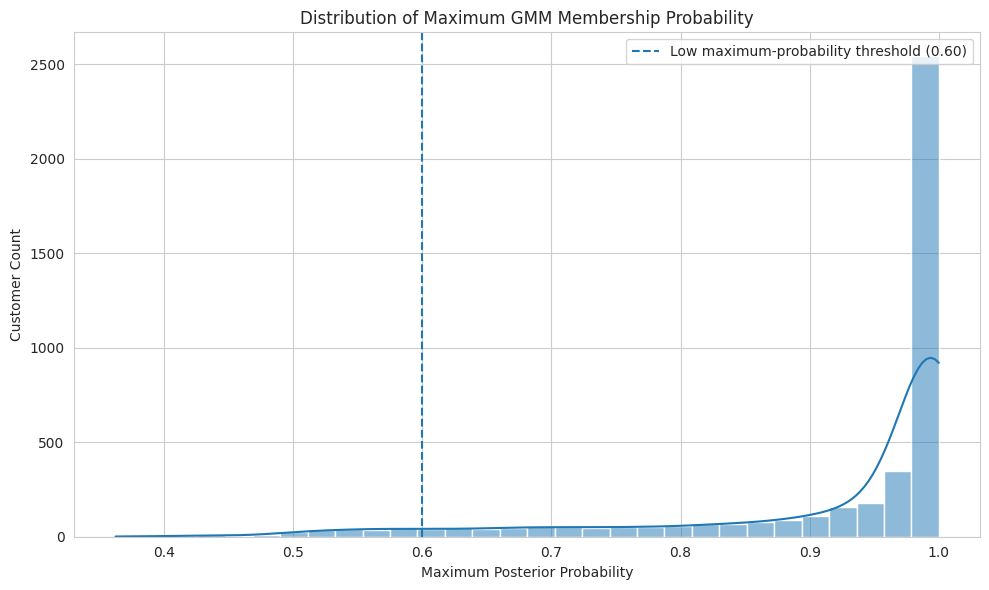

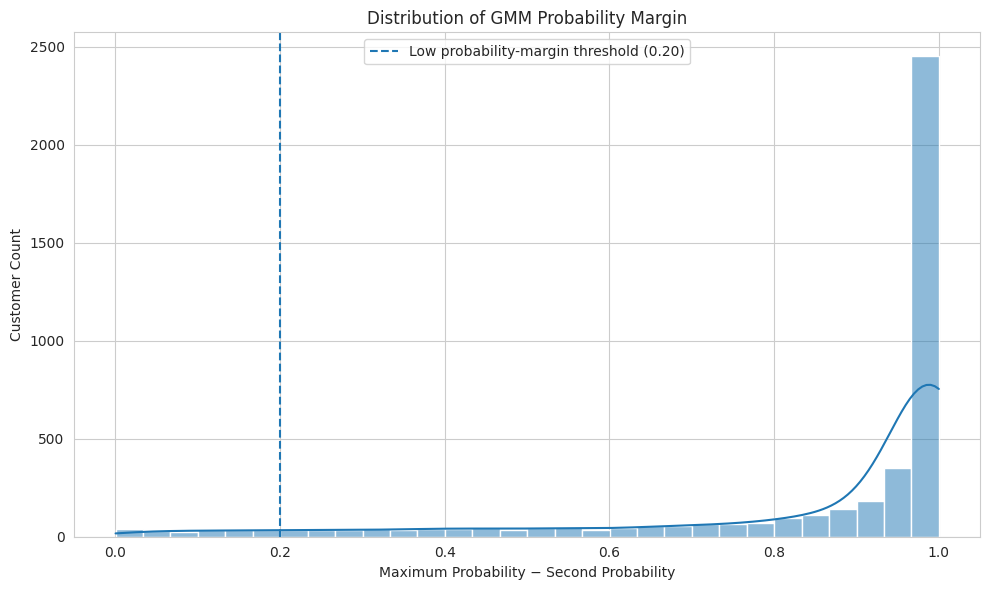

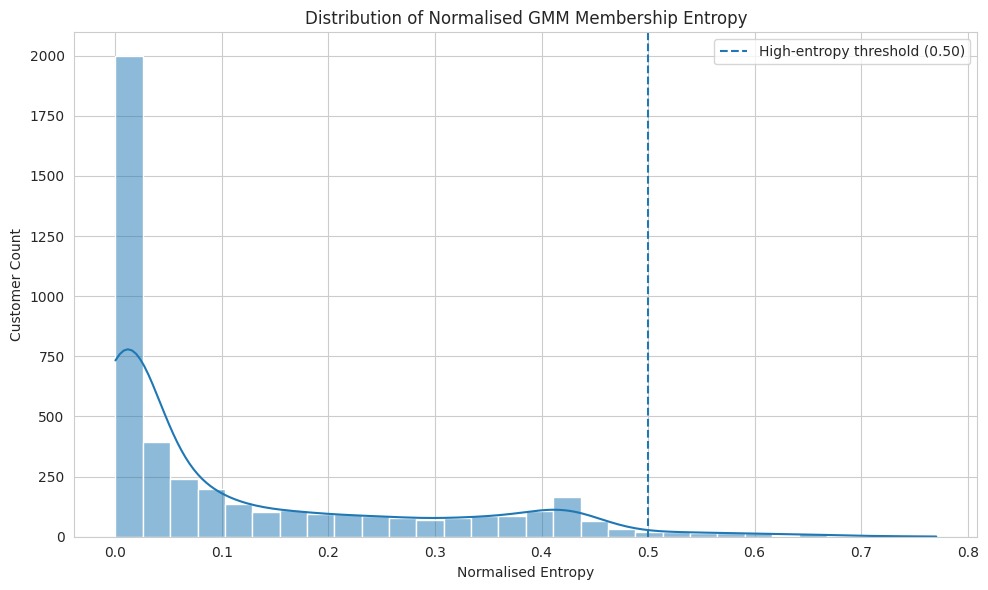

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    membership_data[
        "Maximum_Probability"
    ],
    bins=30,
    kde=True
)

plt.axvline(
    LOW_MAX_PROBABILITY_THRESHOLD,
    linestyle="--",
    label=(
        "Low maximum-probability threshold "
        f"({LOW_MAX_PROBABILITY_THRESHOLD:.2f})"
    )
)

plt.title(
    "Distribution of Maximum GMM Membership Probability"
)
plt.xlabel("Maximum Posterior Probability")
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "maximum_membership_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(
    membership_data[
        "Probability_Margin"
    ],
    bins=30,
    kde=True
)

plt.axvline(
    LOW_PROBABILITY_MARGIN_THRESHOLD,
    linestyle="--",
    label=(
        "Low probability-margin threshold "
        f"({LOW_PROBABILITY_MARGIN_THRESHOLD:.2f})"
    )
)

plt.title(
    "Distribution of GMM Probability Margin"
)
plt.xlabel(
    "Maximum Probability − Second Probability"
)
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "probability_margin_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(
    membership_data[
        "Normalised_Entropy"
    ],
    bins=30,
    kde=True
)

plt.axvline(
    HIGH_ENTROPY_THRESHOLD,
    linestyle="--",
    label=(
        "High-entropy threshold "
        f"({HIGH_ENTROPY_THRESHOLD:.2f})"
    )
)

plt.title(
    "Distribution of Normalised GMM Membership Entropy"
)
plt.xlabel("Normalised Entropy")
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "membership_entropy_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

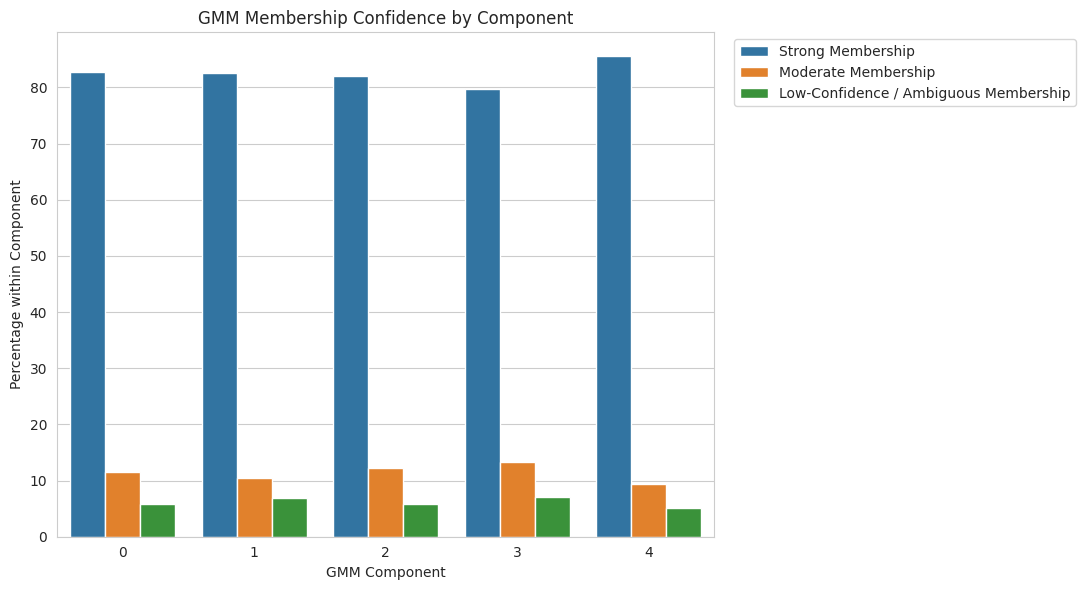

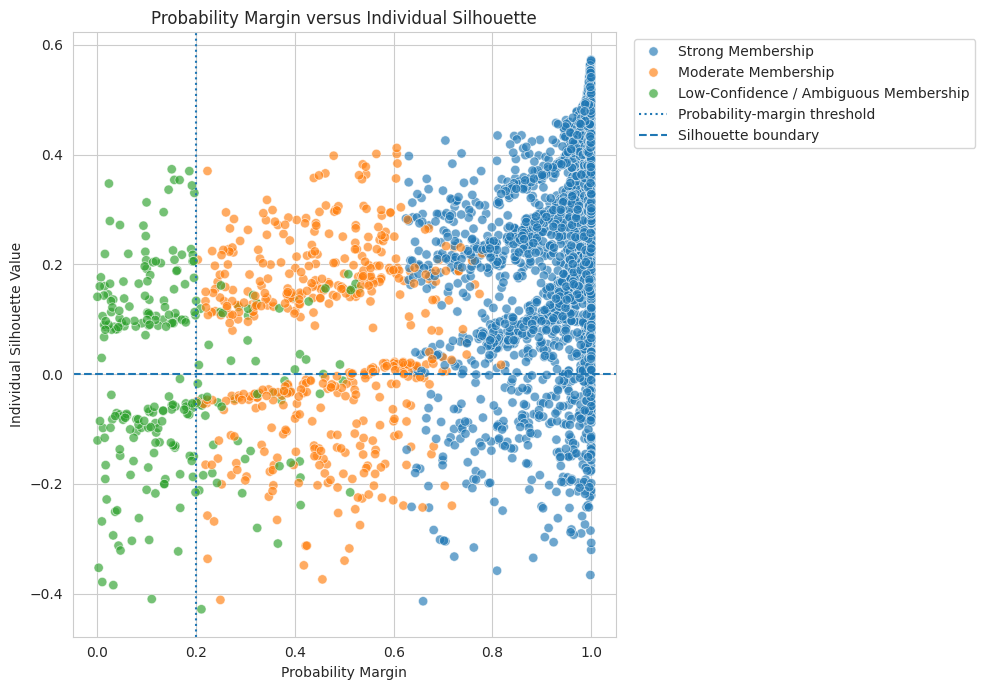

In [ ]:
component_confidence_plot_data = (
    membership_data
    .groupby(
        [
            "GMM_Component",
            "Membership_Confidence_Category"
        ]
    )
    .size()
    .reset_index(
        name="Customer_Count"
    )
)

component_confidence_plot_data[
    "Customer_Percentage_Within_Component"
] = (
    component_confidence_plot_data[
        "Customer_Count"
    ]
    / component_confidence_plot_data
    .groupby(
        "GMM_Component"
    )[
        "Customer_Count"
    ]
    .transform("sum")
    * 100
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=component_confidence_plot_data,
    x="GMM_Component",
    y="Customer_Percentage_Within_Component",
    hue="Membership_Confidence_Category",
    hue_order=[
        "Strong Membership",
        "Moderate Membership",
        "Low-Confidence / Ambiguous Membership"
    ]
)

plt.title(
    "GMM Membership Confidence by Component"
)
plt.xlabel("GMM Component")
plt.ylabel("Percentage within Component")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "membership_confidence_by_component.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=membership_data,
    x="Probability_Margin",
    y="Silhouette_Value",
    hue="Membership_Confidence_Category",
    hue_order=[
        "Strong Membership",
        "Moderate Membership",
        "Low-Confidence / Ambiguous Membership"
    ],
    alpha=0.65,
    s=45
)

plt.axvline(
    LOW_PROBABILITY_MARGIN_THRESHOLD,
    linestyle=":",
    label="Probability-margin threshold"
)

plt.axhline(
    0,
    linestyle="--",
    label="Silhouette boundary"
)

plt.title(
    "Probability Margin versus Individual Silhouette"
)
plt.xlabel("Probability Margin")
plt.ylabel("Individual Silhouette Value")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "probability_margin_vs_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

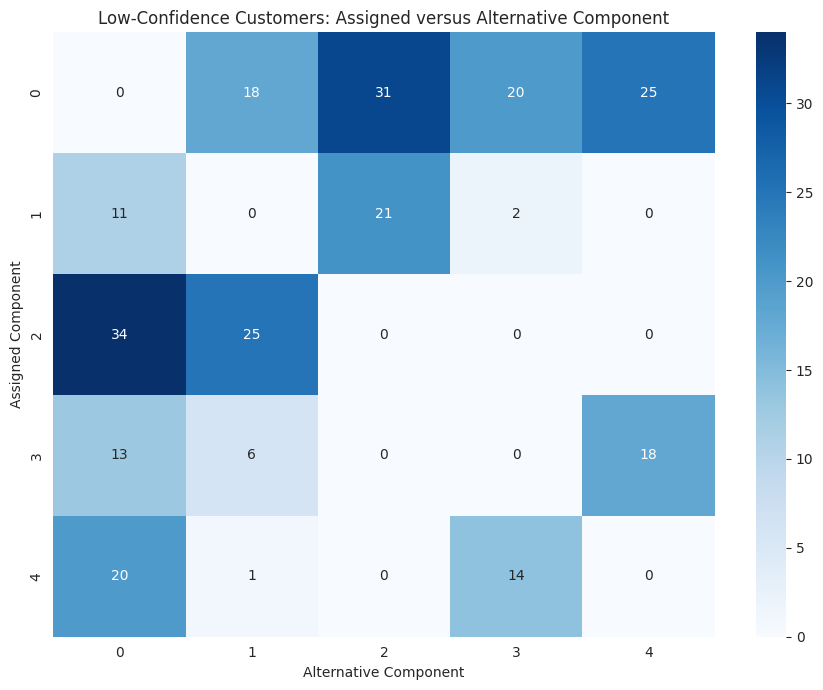

In [ ]:
ambiguous_heatmap = pd.crosstab(
    ambiguous_customers[
        "GMM_Component"
    ],
    ambiguous_customers[
        "Alternative_GMM_Component"
    ]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    ambiguous_heatmap,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Low-Confidence Customers: Assigned versus Alternative Component"
)
plt.xlabel("Alternative Component")
plt.ylabel("Assigned Component")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "ambiguous_component_overlap_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Export membership-analysis datasets and tables

In [ ]:
membership_data.to_csv(
    DATASETS_DIR
    / "final_gmm_customer_membership_analysis.csv",
    index=False
)

ambiguous_customers.to_csv(
    DATASETS_DIR
    / "final_gmm_low_confidence_customers.csv",
    index=False
)

condition_summary.to_csv(
    TABLES_DIR
    / "gmm_membership_condition_summary.csv",
    index=False
)

confidence_category_summary.to_csv(
    TABLES_DIR
    / "gmm_membership_confidence_summary.csv",
    index=False
)

probability_descriptive_summary.to_csv(
    TABLES_DIR
    / "gmm_probability_descriptive_summary.csv"
)

component_confidence_summary.to_csv(
    TABLES_DIR
    / "gmm_membership_confidence_by_component.csv",
    index=False
)

component_overlap_summary.to_csv(
    TABLES_DIR
    / "gmm_component_overlap_summary.csv",
    index=False
)

assigned_alternative_matrix.to_csv(
    TABLES_DIR
    / "gmm_assigned_vs_alternative_component_matrix.csv"
)

ambiguous_overlap_matrix.to_csv(
    TABLES_DIR
    / "gmm_ambiguous_component_overlap_matrix.csv"
)

probability_silhouette_cross_summary.to_csv(
    TABLES_DIR
    / "gmm_probability_silhouette_cross_summary.csv",
    index=False
)

confidence_silhouette_matrix.to_csv(
    TABLES_DIR
    / "gmm_confidence_silhouette_matrix.csv"
)

maximum_probability_sensitivity.to_csv(
    TABLES_DIR
    / "gmm_maximum_probability_threshold_sensitivity.csv",
    index=False
)

probability_margin_sensitivity.to_csv(
    TABLES_DIR
    / "gmm_probability_margin_threshold_sensitivity.csv",
    index=False
)

entropy_sensitivity.to_csv(
    TABLES_DIR
    / "gmm_entropy_threshold_sensitivity.csv",
    index=False
)

print(
    "Membership-analysis datasets and tables exported."
)

Membership-analysis datasets and tables exported.


## 15. Run final quality-control checks

In [ ]:
assert len(membership_data) == EXPECTED_CUSTOMERS

assert membership_data[
    "CustomerID"
].is_unique

assert np.array_equal(
    membership_data[
        "GMM_Component"
    ].to_numpy(),
    frozen_labels
)

assert np.allclose(
    reproduced_probabilities.sum(axis=1),
    1.0
)

assert membership_data[
    "Maximum_Probability"
].between(
    0,
    1,
    inclusive="both"
).all()

assert membership_data[
    "Second_Probability"
].between(
    0,
    1,
    inclusive="both"
).all()

assert membership_data[
    "Probability_Margin"
].between(
    0,
    1,
    inclusive="both"
).all()

assert membership_data[
    "Normalised_Entropy"
].between(
    0,
    1,
    inclusive="both"
).all()

assert (
    membership_data[
        "Alternative_GMM_Component"
    ]
    != membership_data[
        "GMM_Component"
    ]
).all()

assert (
    confidence_category_summary[
        "Customer_Count"
    ].sum()
    == EXPECTED_CUSTOMERS
)

assert (
    len(ambiguous_customers)
    == int(
        combined_ambiguous_flag.sum()
    )
)

required_outputs = [
    DATASETS_DIR
    / "final_gmm_customer_membership_analysis.csv",
    DATASETS_DIR
    / "final_gmm_low_confidence_customers.csv",
    TABLES_DIR
    / "gmm_membership_condition_summary.csv",
    TABLES_DIR
    / "gmm_membership_confidence_summary.csv",
    TABLES_DIR
    / "gmm_membership_confidence_by_component.csv",
    TABLES_DIR
    / "gmm_component_overlap_summary.csv",
    TABLES_DIR
    / "gmm_probability_silhouette_cross_summary.csv",
    TABLES_DIR
    / "gmm_probability_margin_threshold_sensitivity.csv"
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing required outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Customer count remains 4,338",
        "CustomerID values are unique",
        "Frozen component assignments reproduced",
        "Posterior probabilities sum to one",
        "Maximum probabilities valid",
        "Second probabilities valid",
        "Probability margins valid",
        "Normalised entropy valid",
        "Alternative component differs from assigned component",
        "Confidence category counts sum to 4,338",
        "Low-confidence dataset count consistent",
        "Required output files created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    QUALITY_DIR
    / "gmm_membership_analysis_quality_checks.csv",
    index=False
)

print(
    "All GMM membership-analysis quality checks passed."
)

,Quality_Check,Passed
0,"Customer count remains 4,338",True
1,CustomerID values are unique,True
2,Frozen component assignments reproduced,True
3,Posterior probabilities sum to one,True
4,Maximum probabilities valid,True
5,Second probabilities valid,True
6,Probability margins valid,True
7,Normalised entropy valid,True
8,Alternative component differs from assigned co...,True
9,"Confidence category counts sum to 4,338",True


All GMM membership-analysis quality checks passed.


## 16. Create the supervisor-ready summary

In [ ]:
ambiguous_count = int(
    combined_ambiguous_flag.sum()
)

ambiguous_percentage = float(
    combined_ambiguous_flag.mean()
    * 100
)

negative_silhouette_count = int(
    (
        individual_silhouette < 0
    ).sum()
)

negative_silhouette_percentage = float(
    (
        individual_silhouette < 0
    ).mean()
    * 100
)

supervisor_summary = f'''
FINAL GMM C5 CUSTOMER MEMBERSHIP ANALYSIS

Frozen model
------------
Configuration: GMM_C5_spherical
Customers: {len(X):,}
Features: {len(FEATURE_COLUMNS)}
Components: {EXPECTED_COMPONENTS}
Overall Silhouette Score: {overall_silhouette:.4f}

Probability evidence
--------------------
Mean maximum probability:
{maximum_probability.mean():.4f}

Median maximum probability:
{np.median(maximum_probability):.4f}

Mean probability margin:
{probability_margin.mean():.4f}

Median probability margin:
{np.median(probability_margin):.4f}

Mean normalised entropy:
{normalised_entropy.mean():.4f}

Customer-level review conditions
--------------------------------
Maximum probability below {LOW_MAX_PROBABILITY_THRESHOLD:.2f}:
{int(low_max_probability_flag.sum()):,}
({low_max_probability_flag.mean() * 100:.2f}%)

Probability margin below {LOW_PROBABILITY_MARGIN_THRESHOLD:.2f}:
{int(low_probability_margin_flag.sum()):,}
({low_probability_margin_flag.mean() * 100:.2f}%)

Normalised entropy above {HIGH_ENTROPY_THRESHOLD:.2f}:
{int(high_entropy_flag.sum()):,}
({high_entropy_flag.mean() * 100:.2f}%)

Combined low-confidence / ambiguous group:
{ambiguous_count:,}
({ambiguous_percentage:.2f}%)

Negative-Silhouette customers:
{negative_silhouette_count:,}
({negative_silhouette_percentage:.2f}%)

Interpretation
--------------
The combined low-confidence group is a descriptive customer-review
group. It does not represent supervised misclassification.

Posterior probability, probability margin, entropy and Silhouette
measure related but different aspects of customer membership.

The next stage should compare these frozen GMM assignments and
confidence measures with the frozen K-Means K=5 model.
'''.strip()

with open(
    RESULTS_DIR
    / "supervisor_gmm_membership_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

FINAL GMM C5 CUSTOMER MEMBERSHIP ANALYSIS

Frozen model
------------
Configuration: GMM_C5_spherical
Customers: 4,338
Features: 7
Components: 5
Overall Silhouette Score: 0.2299

Probability evidence
--------------------
Mean maximum probability:
0.9221

Median maximum probability:
0.9908

Mean probability margin:
0.8503

Median probability margin:
0.9827

Mean normalised entropy:
0.1201

Customer-level review conditions
--------------------------------
Maximum probability below 0.60:
227
(5.23%)

Probability margin below 0.20:
194
(4.47%)

Normalised entropy above 0.50:
103
(2.37%)

Combined low-confidence / ambiguous group:
259
(5.97%)

Negative-Silhouette customers:
628
(14.48%)

Interpretation
--------------
The combined low-confidence group is a descriptive customer-review
group. It does not represent supervised misclassification.

Posterior probability, probability margin, entropy and Silhouette
measure related but different aspects of customer membership.

The next stage should c

## 17. Save the membership-analysis manifest

In [ ]:
membership_manifest = {
    "model": {
        "configuration": "GMM_C5_spherical",
        "n_components": EXPECTED_COMPONENTS,
        "covariance_type": (
            EXPECTED_COVARIANCE_TYPE
        ),
        "retrained_in_this_notebook": False
    },
    "dataset": {
        "customers": int(
            len(X)
        ),
        "features": FEATURE_COLUMNS
    },
    "main_descriptive_thresholds": {
        "low_maximum_probability": (
            LOW_MAX_PROBABILITY_THRESHOLD
        ),
        "low_probability_margin": (
            LOW_PROBABILITY_MARGIN_THRESHOLD
        ),
        "high_normalised_entropy": (
            HIGH_ENTROPY_THRESHOLD
        ),
        "strong_membership_minimum_probability": (
            MODERATE_MAX_PROBABILITY_THRESHOLD
        ),
        "strong_membership_minimum_margin": (
            MODERATE_PROBABILITY_MARGIN_THRESHOLD
        ),
        "strong_membership_maximum_entropy": (
            MODERATE_ENTROPY_THRESHOLD
        ),
        "note": (
            "Transparent dissertation-specific review "
            "conditions rather than universal GMM standards."
        )
    },
    "outputs": {
        "customer_membership_dataset": (
            "final_gmm_customer_membership_analysis.csv"
        ),
        "low_confidence_dataset": (
            "final_gmm_low_confidence_customers.csv"
        ),
        "component_overlap_summary": (
            "gmm_component_overlap_summary.csv"
        )
    },
    "next_step": (
        "Compare frozen K-Means K=5 and frozen "
        "GMM C5 spherical assignments."
    )
}

with open(
    RESULTS_DIR
    / "gmm_membership_analysis_manifest.json",
    "w"
) as file:
    json.dump(
        membership_manifest,
        file,
        indent=4
    )

print(
    "Membership-analysis manifest saved."
)

Membership-analysis manifest saved.


## 18. Create the final results ZIP

In [ ]:
zip_path = shutil.make_archive(
    base_name=(
        "/content/"
        "GMM_C5_Membership_Probability_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("GMM MEMBERSHIP ANALYSIS COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nKey outputs:")
print("1. final_gmm_customer_membership_analysis.csv")
print("2. final_gmm_low_confidence_customers.csv")
print("3. gmm_membership_condition_summary.csv")
print("4. gmm_membership_confidence_summary.csv")
print("5. gmm_membership_confidence_by_component.csv")
print("6. gmm_component_overlap_summary.csv")
print("7. gmm_probability_silhouette_cross_summary.csv")
print("8. supervisor_gmm_membership_summary.txt")

GMM MEMBERSHIP ANALYSIS COMPLETED

Results folder:
/content/GMM_C5_Membership_Probability_Results

ZIP archive:
/content/GMM_C5_Membership_Probability_Results.zip

Key outputs:
1. final_gmm_customer_membership_analysis.csv
2. final_gmm_low_confidence_customers.csv
3. gmm_membership_condition_summary.csv
4. gmm_membership_confidence_summary.csv
5. gmm_membership_confidence_by_component.csv
6. gmm_component_overlap_summary.csv
7. gmm_probability_silhouette_cross_summary.csv
8. supervisor_gmm_membership_summary.txt


## Final reporting guidance

Report the GMM result using two separate forms of evidence:

### Model-level reliability

- random-seed ARI;
- repeated 80% subsampling ARI;
- convergence;
- component feasibility.

### Customer-level membership evidence

- maximum posterior probability;
- probability margin;
- normalised entropy;
- alternative component;
- individual Silhouette Value;
- descriptive low-confidence group.

Do not describe the low-confidence group as a confirmed misclassification
rate.